In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [2]:
from datasets import load_dataset

ds = load_dataset("HuggingFaceM4/ChartQA")

C:\Users\Sonic\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
ds["train"].column_names

['image', 'query', 'label', 'human_or_machine']

In [4]:
train_ds = ds["train"]
val_ds   = ds["val"]
test_ds  = ds["test"]

train_ds[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=422x359>,
 'query': 'Is the value of Favorable 38 in 2015?',
 'label': ['Yes'],
 'human_or_machine': 0}

## Gemini

In [5]:
import os
import pandas as pd
from dotenv import load_dotenv
from google import genai

load_dotenv()
client = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

In [6]:
# Model and sampling settings
MODEL = "gemini-2.5-flash"
N = 1000                                  # number of samples

# Output settings
OUTPUT_FILE = "data/results.csv"
os.makedirs("data", exist_ok=True)

# Gemini Rate Settings
SAVE_EVERY = 5                          # checkpoint frequency
SLEEP_SECONDS = 2                      

In [7]:
import os
import re
import time

# ---------------------------
# Load existing results (if any)
# ---------------------------
if os.path.exists(OUTPUT_FILE):
    df_existing = pd.read_csv(OUTPUT_FILE)
    processed_indices = set(df_existing["index"].tolist())
    results = df_existing.to_dict("records")
    start_i = max(processed_indices) + 1
    print(f"Resuming from index {start_i} ({len(processed_indices)} already done)")
else:
    results = []
    processed_indices = set()
    start_i = 0
    print("Starting fresh run")

# ---------------------------
# Evaluation loop
# ---------------------------

for i in range(start_i, min(N, len(train_ds))):
    if i in processed_indices:
        continue

    print(f"Processing sample {i+1:6d}/{N}")

    example = train_ds[i]
    image = example["image"]
    question = example["query"]
    true_label = example["label"][0]
    question_type = example["human_or_machine"] # 0/"human" or 1/"machine"

    prompt = f"""Answer the question about this chart.
                Question: {question}
                Provide only the final answer.

                Format your answer as a single word or number, without any explanation or additional text or punctuation.
                Percentages should be provided in the same format as the provided chart. Otherwise, use decimal form (e.g., 0.25 for 25%).
                Cases where multiple answers are possible should be separated by commas and contained in square brackets (e.g., [Answer1, Answer2]).
            """

    try:
        response = client.models.generate_content(
            model=MODEL,
            contents=[prompt, image],
        )
        prediction = (response.text or "").strip()
    except Exception as e:
        print(f"Error at index {i+1}")
        prediction = "ERROR"

        # redo this iteration
        i -= 1
        continue

    correct = int(
        re.sub(r"[ %]+", "", str(prediction).strip().lower()) ==
        re.sub(r"[ %]+", "", str(true_label).strip().lower())
    )

    results.append({
        "index": i,
        "query": question,
        "question_type": question_type,
        "true_label": true_label,
        "prediction": prediction,
        "correct": correct
    })

    # ---------------------------
    # Checkpoint save
    # ---------------------------
    if (len(results) % SAVE_EVERY) == 0:
        pd.DataFrame(results).to_csv(OUTPUT_FILE, index=False)
        print(f"Checkpoint saved ({len(results)} rows)")

    time.sleep(SLEEP_SECONDS)

# ---------------------------
# Final save
# ---------------------------
pd.DataFrame(results).to_csv(OUTPUT_FILE, index=False)
print(f"Finished. Saved {len(results)} rows to {OUTPUT_FILE}")

Resuming from index 514 (500 already done)
Processing sample    515/1000
Processing sample    516/1000
Processing sample    517/1000
Processing sample    518/1000
Processing sample    519/1000
Checkpoint saved (505 rows)
Processing sample    520/1000
Processing sample    521/1000
Processing sample    522/1000
Processing sample    523/1000
Processing sample    524/1000
Checkpoint saved (510 rows)
Processing sample    525/1000
Processing sample    526/1000
Processing sample    527/1000
Processing sample    528/1000
Processing sample    529/1000
Checkpoint saved (515 rows)
Processing sample    530/1000
Processing sample    531/1000
Processing sample    532/1000
Processing sample    533/1000
Processing sample    534/1000
Checkpoint saved (520 rows)
Processing sample    535/1000
Processing sample    536/1000
Processing sample    537/1000
Processing sample    538/1000
Processing sample    539/1000
Checkpoint saved (525 rows)
Processing sample    540/1000
Processing sample    541/1000
Process

In [15]:
import pandas as pd
import re

# Load the results
df = pd.read_csv(OUTPUT_FILE)

def normalize_value(val):
    val = str(val).strip().lower()
    if val.endswith('%'):
        try:
            return float(val[:-1]) / 100
        except ValueError:
            return val
    else:
        try:
            return float(val)
        except ValueError:
            return val

def numeric_equivalent(a, b, tol=1e-6):
    """
    Treat values as equivalent if they match directly
    OR if one is the percentage-scaled version of the other.
    
    Examples considered equal:
    0.39 == 0.39
    0.39 == 39
    39 == 0.39
    39% == 0.39
    39% == 39
    """
    candidates_a = {a, a / 100, a * 100}
    candidates_b = {b, b / 100, b * 100}

    for x in candidates_a:
        for y in candidates_b:
            if abs(x - y) < tol:
                return True
    return False

# Function to check if two values are equivalent considering percentage/decimal/integer format
def is_equivalent(true_val, pred_val):
    norm_true = normalize_value(true_val)
    norm_pred = normalize_value(pred_val)

    if isinstance(norm_true, float) and isinstance(norm_pred, float):
        return numeric_equivalent(norm_true, norm_pred)
    else:
        return re.sub(r"[ %]+", "", str(pred_val).strip().lower()) == \
               re.sub(r"[ %]+", "", str(true_val).strip().lower())

# Correct the 'correct' column
corrections_made = 0
for idx, row in df.iterrows():
    if row['correct'] == 0:
        if is_equivalent(row['true_label'], row['prediction']):
            df.at[idx, 'correct'] = 1
            corrections_made += 1

print(f"Corrections made: {corrections_made}")

# Save the corrected results
df.to_csv(OUTPUT_FILE, index=False)
print(f"Corrected results saved to {OUTPUT_FILE}")

Corrections made: 16
Corrected results saved to data/results.csv


In [16]:
correct_pred = df['correct'].sum()
total_samples = len(df)
accuracy = correct_pred / total_samples

print(f"Accuracy: {accuracy:.4f} ({correct_pred} correct out of {total_samples})")


Accuracy: 0.8406 (828 correct out of 985)


In [17]:
import pandas as pd

# Assuming df is already loaded from previous cells
# If not, uncomment: df = pd.read_csv(OUTPUT_FILE)

# Overall accuracy
overall_accuracy = df['correct'].mean()
print(f"Overall Accuracy: {overall_accuracy:.4f}")

# Accuracy by question type
accuracy_by_type = df.groupby('question_type')['correct'].mean()
print("\nAccuracy by Question Type:")
for qtype, acc in accuracy_by_type.items():
    type_name = "Human" if qtype == 0 else "Machine"
    count = df[df['question_type'] == qtype].shape[0]
    print(f"{type_name}: {acc:.4f} ({count} samples)")

# Total correct and incorrect
total_correct = df['correct'].sum()
total_incorrect = len(df) - total_correct
print(f"\nTotal Correct: {total_correct}")
print(f"Total Incorrect: {total_incorrect}")

# Perhaps error analysis: show some incorrect predictions
incorrect_df = df[df['correct'] == 0]
print(f"\nSample Incorrect Predictions:")
for idx, row in incorrect_df.head(5).iterrows():
    print(f"Index {row['index']}: Query: {row['query'][:50]}... True: {row['true_label']}, Pred: {row['prediction']}")

Overall Accuracy: 0.8406

Accuracy by Question Type:
Human: 0.8406 (985 samples)

Total Correct: 828
Total Incorrect: 157

Sample Incorrect Predictions:
Index 0: Query: Is the value of Favorable 38 in 2015?... True: Yes, Pred: 38
Index 1: Query: How many values are below 40 in Unfavorable graph?... True: 6, Pred: 7
Index 3: Query: What is the sum favourable  value in the year 2014... True: 95, Pred: 92
Index 31: Query: What's the median value of green graph from 2011 t... True: 61, Pred: 51
Index 56: Query: Which line has bigger changes in values?... True: East Germany, Pred: West Germany


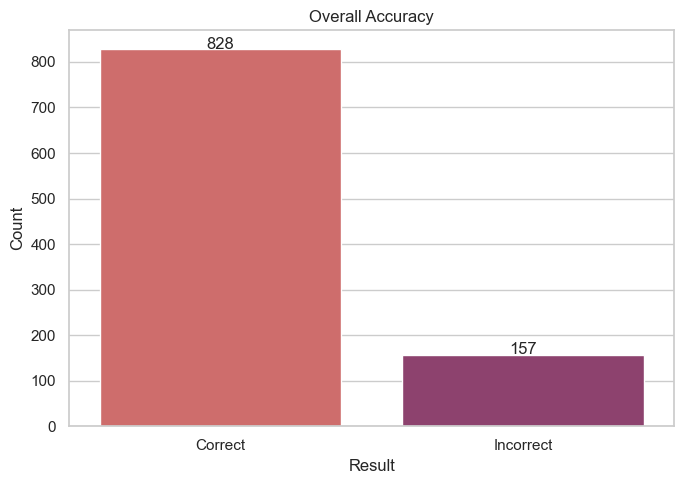

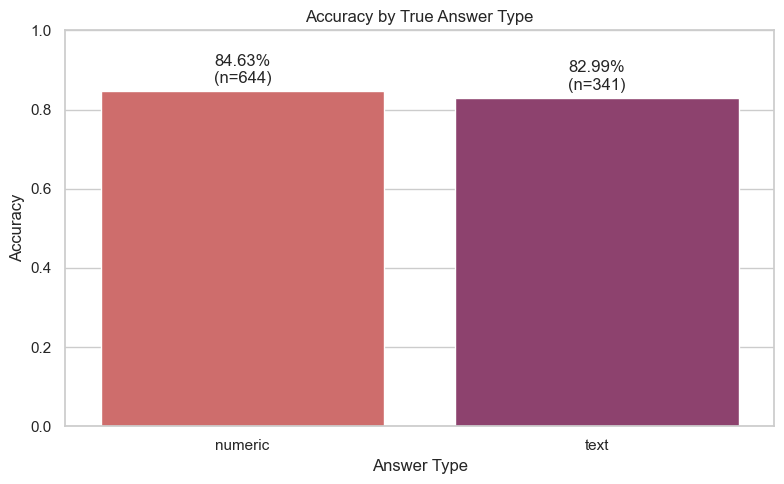

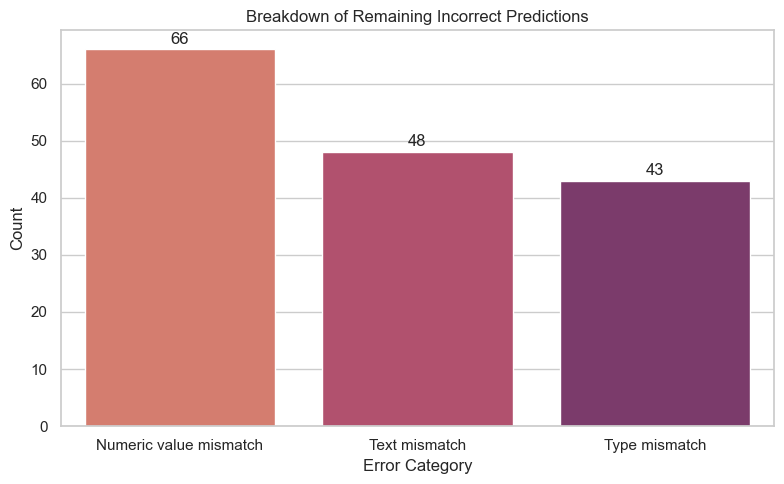

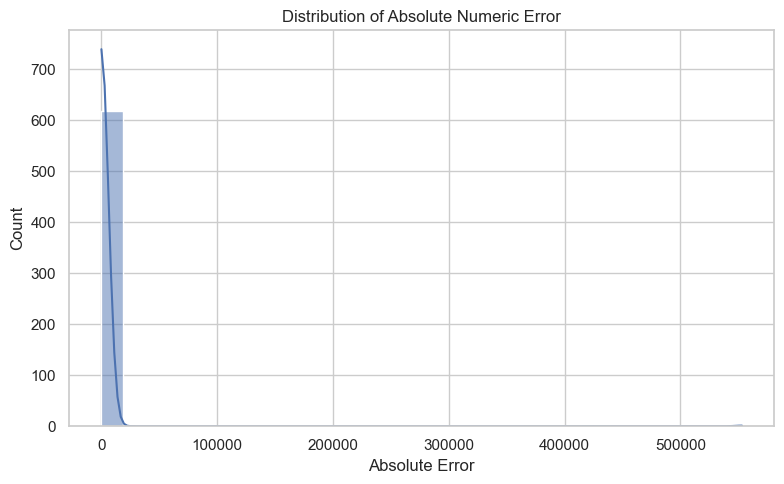

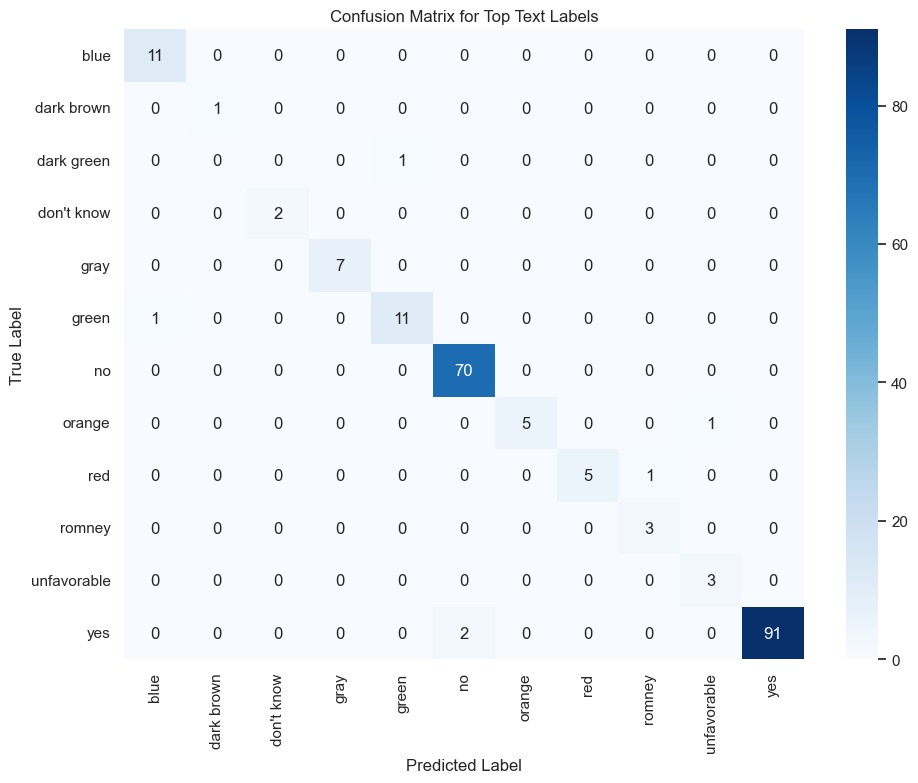

In [23]:
import seaborn as sns

sns.set_theme(style="whitegrid")

# -----------------------------
# Helper functions
# -----------------------------
def classify_answer_type(val):
    s = str(val).strip()
    if s.endswith('%'):
        return "percentage"
    
    s_clean = s.replace(",", "")
    try:
        float(s_clean)
        return "numeric"
    except ValueError:
        return "text"

def normalize_numeric(val):
    s = str(val).strip().lower().replace(",", "")
    if s.endswith('%'):
        try:
            return float(s[:-1]) / 100
        except ValueError:
            return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

def normalize_text(val):
    return re.sub(r"\s+", " ", str(val).strip().lower())

# -----------------------------
# Derived columns
# -----------------------------
df["true_type"] = df["true_label"].apply(classify_answer_type)
df["pred_type"] = df["prediction"].apply(classify_answer_type)
df["true_num"] = df["true_label"].apply(normalize_numeric)
df["pred_num"] = df["prediction"].apply(normalize_numeric)

# =========================================================
# 1. Overall Accuracy
# =========================================================
overall_counts = (
    df["correct"]
    .map({1: "Correct", 0: "Incorrect"})
    .value_counts()
    .reset_index()
)
overall_counts.columns = ["Result", "Count"]

plt.figure(figsize=(7,5))
ax = sns.barplot(data=overall_counts, x="Result", y="Count",
    hue="Result",
    palette="flare",
    legend=False)
ax.set_title("Overall Accuracy")
for i, row in overall_counts.iterrows():
    ax.text(i, row["Count"] + 1, str(row["Count"]), ha="center")
plt.tight_layout()
plt.show()

# =========================================================
# 3. Accuracy by Answer Type
# =========================================================
accuracy_by_type = (
    df.groupby("true_type")["correct"]
    .mean()
    .reset_index()
)
accuracy_by_type.columns = ["Answer Type", "Accuracy"]

counts_by_type = (
    df.groupby("true_type")
    .size()
    .reset_index(name="n")
)

accuracy_by_type = accuracy_by_type.merge(
    counts_by_type, left_on="Answer Type", right_on="true_type"
).drop(columns=["true_type"])

plt.figure(figsize=(8,5))
ax = sns.barplot(data=accuracy_by_type, x="Answer Type", y="Accuracy",
    hue="Answer Type",
    palette="flare",
    legend=False)
ax.set_title("Accuracy by True Answer Type")
ax.set_ylim(0, 1)

for i, row in accuracy_by_type.iterrows():
    ax.text(i, row["Accuracy"] + 0.02, f"{row['Accuracy']:.2%}\n(n={row['n']})", ha="center")

plt.tight_layout()
plt.show()

# =========================================================
# 5. Error Breakdown of Remaining Incorrect Answers
# =========================================================
incorrect = df[df["correct"] == 0].copy()

def error_category(row):
    if row["true_type"] != row["pred_type"]:
        return "Type mismatch"
    elif row["true_type"] in ["numeric", "percentage"] and row["pred_type"] in ["numeric", "percentage"]:
        return "Numeric value mismatch"
    else:
        return "Text mismatch"

incorrect["error_category"] = incorrect.apply(error_category, axis=1)

error_counts = (
    incorrect["error_category"]
    .value_counts()
    .reset_index()
)
error_counts.columns = ["Error Category", "Count"]

plt.figure(figsize=(8,5))
ax = sns.barplot(data=error_counts, x="Error Category", y="Count", 
    hue="Error Category",
    palette="flare",
    legend=False)
ax.set_title("Breakdown of Remaining Incorrect Predictions")
for i, row in error_counts.iterrows():
    ax.text(i, row["Count"] + 1, str(row["Count"]), ha="center")
plt.tight_layout()
plt.show()

# =========================================================
# 6. Distribution of Numeric Error
# =========================================================
numeric_df = df[df["true_num"].notna() & df["pred_num"].notna()].copy()
numeric_df["abs_error"] = (numeric_df["pred_num"] - numeric_df["true_num"]).abs()

plt.figure(figsize=(8,5))
sns.histplot(data=numeric_df, x="abs_error", bins=30, kde=True)
plt.title("Distribution of Absolute Numeric Error")
plt.xlabel("Absolute Error")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# =========================================================
# 7. Confusion Matrix for Text Answers
# =========================================================
text_df = df[
    (df["true_type"] == "text") &
    (df["pred_type"] == "text")
].copy()

text_df["true_norm"] = text_df["true_label"].apply(normalize_text)
text_df["pred_norm"] = text_df["prediction"].apply(normalize_text)

# keep only top labels so the heatmap stays readable
top_labels = text_df["true_norm"].value_counts().head(12).index
text_df_small = text_df[
    text_df["true_norm"].isin(top_labels) &
    text_df["pred_norm"].isin(top_labels)
]

conf_matrix = pd.crosstab(text_df_small["true_norm"], text_df_small["pred_norm"])

plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix for Top Text Labels")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()